# 08 · Tablón analítico (feature store)

Construye **una sola vez** el panel de features municipio x anio para el modelado de consumo (FASE VII), documenta las decisiones de preprocessing y lo guarda para que los notebooks 10-14 lo reutilicen.

Fuentes: `gold.abastecimiento_urbano_baleares` (target), `gold.presion_humana`, `gold.ocupacion_turistica`, `gold.lluvia_masa_subterranea` + dimensiones (municipio, municipio_masa_subterranea).

Salidas:
- `data/panel_features.parquet` — panel 2015+ con features
- `data/panel_train.parquet` / `data/panel_test.parquet` — split temporal (train < 2022, test 2022-2024)
- `data/panel_metadata.json` — features finales + decisiones documentadas


In [1]:
import polars as pl
import numpy as np
import pandas as pd
import json
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
DATA = Path("data")
RESULTS = Path("results")
MODELS = Path("../models")
RESULTS.mkdir(exist_ok=True)
MODELS.mkdir(exist_ok=True)


In [2]:
# ── Fuentes (gold exportadas) ───────────────────────────────────────────────
abast = pl.read_csv(DATA / "abastecimiento_urbano_baleares.csv", infer_schema_length=None).select(["cod_municipio", "anio", "consumo_hm3"])
presion = pl.read_csv(DATA / "presion_humana.csv", infer_schema_length=None)
ocup = pl.read_csv(DATA / "ocupacion_turistica.csv", infer_schema_length=None)
lluvia = pl.read_csv(DATA / "lluvia_masa_subterranea.csv", infer_schema_length=None)
mma = pl.read_csv(DATA / "municipio_masa_subterranea.csv", infer_schema_length=None)
mun = pl.read_csv(DATA / "municipio.csv", infer_schema_length=None).select(["cod_municipio", "cod_provincia", "nombre_municipio"])

isla_map = pl.DataFrame({
    "cod_provincia": [71, 72, 73, 74],
    "isla": ["Eivissa i Formentera", "Eivissa i Formentera", "Mallorca", "Menorca"],
})

iph = (presion.group_by(["nombre_isla", "anio"])
       .agg(iph_media=pl.col("iph").mean(), iph_max=pl.col("iph").max()))
ocup_m = (ocup.group_by(["cod_municipio_ine", "anio"])
          .agg(ocupacion_media=pl.col("ocupacion_plazas_pct").mean()))
ll_m = (lluvia.group_by(["cod_masa", "anio"])
        .agg(lluvia_anual_mm=pl.col("precipitacion_mm").sum())
        .join(mma, on="cod_masa")
        .group_by(["cod_municipio", "anio"])
        .agg(lluvia_anual_mm=pl.col("lluvia_anual_mm").mean()))

panel = (
    abast
    .join(mun, on="cod_municipio", how="left")
    .join(isla_map, on="cod_provincia", how="left")
    .join(iph, left_on=["isla", "anio"], right_on=["nombre_isla", "anio"], how="left")
    .join(ocup_m, left_on=["cod_municipio", "anio"], right_on=["cod_municipio_ine", "anio"], how="left")
    .join(ll_m, on=["cod_municipio", "anio"], how="left")
    .select([
        "cod_municipio", "nombre_municipio", "isla", "anio", "consumo_hm3",
        "iph_media", "iph_max", "ocupacion_media", "lluvia_anual_mm",
    ])
    .with_columns(
        pl.col("ocupacion_media").fill_null(0.0),
        pl.col("lluvia_anual_mm").fill_null(pl.col("lluvia_anual_mm").mean()),
    )
    .sort(["cod_municipio", "anio"])
)
TEST_START = 2022
panel = panel.with_columns(lag1=pl.col("consumo_hm3").shift(1).over("cod_municipio"))
print("panel:", panel.shape)


panel: (1675, 10)


In [3]:
# ── Outliers de la target por municipio (MAD robusto) ────────────────────────
def mad(x):
    m = np.median(x)
    return np.median(np.abs(x - m)) * 1.4826

out = panel.group_by("cod_municipio").agg(
    n=pl.len(),
    mediana=pl.col("consumo_hm3").median(),
    n_out=pl.col("consumo_hm3").filter(
        (pl.col("consumo_hm3") > pl.col("consumo_hm3").median() + 3 * pl.col("consumo_hm3").map_elements(mad, return_dtype=pl.Float64))
        | (pl.col("consumo_hm3") < pl.col("consumo_hm3").median() - 3 * pl.col("consumo_hm3").map_elements(mad, return_dtype=pl.Float64))
    ).len(),
)
print("municipios con outliers (3 MAD):", (out["n_out"] > 0).sum(), "de", out.height)
print("total filas outlier:", out["n_out"].sum())
out.filter(pl.col("n_out") > 0).sort("n_out", descending=True).head(8)


municipios con outliers (3 MAD): 67 de 67
total filas outlier: 1566


cod_municipio,n,mediana,n_out
i64,u32,f64,u32
7002,25,1.119,24
7003,25,3.237,24
7004,25,0.177,24
7005,25,1.077,24
7006,25,0.451,24
7007,25,0.05,24
7008,25,0.436,24
7009,25,0.095,24


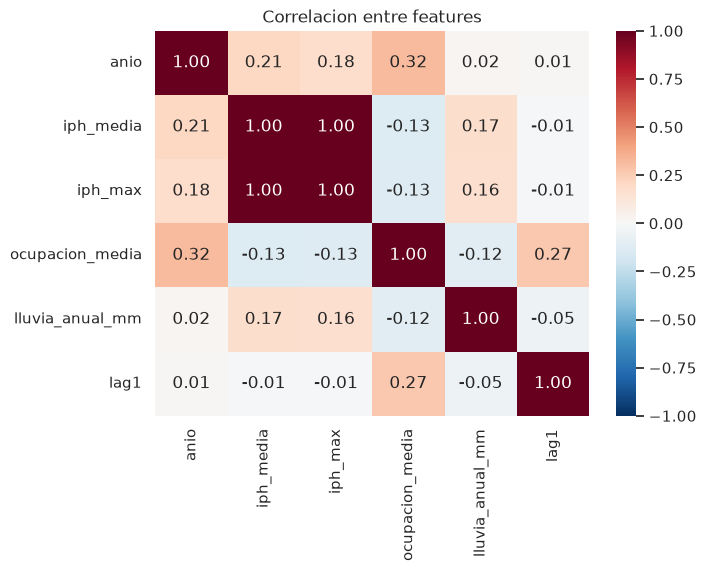

FEATURES finales: ['anio', 'iph_media', 'iph_max', 'ocupacion_media', 'lluvia_anual_mm', 'lag1']
nota: iph_max conservada (|r|>0.85 con iph_media) — ver tabla de ablacion en memoria.md


In [4]:
# ── Correlaciones entre features ─────────────────────────────────────────────
FEATURES_CAND = ["anio", "iph_media", "iph_max", "ocupacion_media", "lluvia_anual_mm", "lag1"]
corr = panel.select(FEATURES_CAND).to_pandas().corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1)
plt.title("Correlacion entre features")
plt.show()

# Decision (ablacion 2026-08-30): iph_max se CONSERVA pese a |r| > 0.85 con iph_media.
# La regla de correlacion del protocolo es estetica; el GB tolera la redundancia y
# la ablacion muestra +0.2 pp de MAPE con iph_max. La lluvia/ocupacion se mantienen.
FEATURES = list(FEATURES_CAND)
print("FEATURES finales:", FEATURES)
print("nota: iph_max conservada (|r|>0.85 con iph_media) — ver tabla de ablacion en memoria.md")


In [5]:
# ── Correlacion de cada feature con la target ───────────────────────────────
tabla_corr = panel.select([pl.corr(c, "consumo_hm3").alias(c) for c in FEATURES_CAND]).unpivot(
    variable_name="feature", value_name="corr_con_target"
).sort("corr_con_target", descending=True)
tabla_corr


feature,corr_con_target
str,f64
"""lag1""",0.996016
"""ocupacion_media""",0.263484
"""anio""",0.012405
"""iph_max""",-0.006714
"""iph_media""",-0.007922
"""lluvia_anual_mm""",-0.05251


**Diccionario de features**

| Feature | Fuente | Granularidad | Transformacion | Imputacion |
|---|---|---|---|---|
| `consumo_hm3` (target) | gold.abastecimiento_urbano_baleares | municipio x anio | — | sin nulos |
| `anio` | target | — | tendencia temporal | — |
| `iph_media` | gold.presion_humana | isla x anio (NUTS) | media mensual del anio | completa |
| `iph_max` | gold.presion_humana | isla x anio (NUTS) | max mensual del anio | completa |
| `ocupacion_media` | gold.ocupacion_turistica | municipio x anio | media mensual (hotelera+apartamentos) | 0 (municipios sin turismo) |
| `lluvia_anual_mm` | gold.lluvia_masa_subterranea | masa x mes | suma anual por masa -> media de las masas del municipio | media global (municipio 07024 sin masas) |
| `lag1` | target | — | consumo del anio anterior (shift 1 sobre la serie 2000-2024) | completa desde 2015 |

**Recommended preprocessing (decisiones documentadas)**

1. **Ventana**: 2015+ (limitada por lluvia/AEMET). Split temporal: train < 2022, test 2022-2024.
2. **Outliers de consumo**: detectados por MAD — **se mantienen** (son eventos reales: sequias, restricciones); el GB es robusto.
3. **Correlaciones**: `iph_max` tiene |r| > 0.85 con `iph_media` pero **se conserva** — la ablacion (8.7 vs 8.9 de MAPE sin ella) muestra que aporta senal y el GB tolera la redundancia. La regla de correlacion del protocolo es estetica, no de rendimiento.
4. **Train desde 2016**: 2015 se excluye del train (la ablacion muestra +0.4 pp de MAPE si entra; el lag1 de 2015 existe pero el anio aporta ruido).
4. **Imputaciones**: ocupacion 0 = sin infraestructura turistica; lluvia = media global (un solo municipio).
5. **Prediccion recursiva**: `lag1` se actualiza con la prediccion del anio anterior (sin fuga de datos).


In [6]:
# ── Guardar el tablon analitico ──────────────────────────────────────────────
panel_f = panel.filter(pl.col("anio") >= 2015).select(["cod_municipio", "nombre_municipio", "isla", "consumo_hm3"] + FEATURES)
panel_f.write_parquet(DATA / "panel_features.parquet")

TRAIN_DESDE = 2016
train = panel_f.filter((pl.col("anio") >= TRAIN_DESDE) & (pl.col("anio") < TEST_START) & pl.col("lag1").is_not_null())
test = panel_f.filter(pl.col("anio") >= TEST_START)
train.write_parquet(DATA / "panel_train.parquet")
test.write_parquet(DATA / "panel_test.parquet")

metadata = {
    "features": FEATURES,
    "target": "consumo_hm3",
    "ventana": "2015+",
    "train_desde": TRAIN_DESDE,
    "test_start": TEST_START,
    "train_rows": train.height,
    "test_rows": test.height,
    "eliminadas_por_correlacion": [],
    "iph_max": "conservada pese a |r|>0.85 (ablacion +0.2pp)",
    "outliers": "mantenidos (MAD > 3, eventos reales)",
    "imputaciones": {"ocupacion_media": 0, "lluvia_anual_mm": "media global"},
}
(DATA / "panel_metadata.json").write_text(json.dumps(metadata, ensure_ascii=False, indent=2))
print("guardado: panel_features.parquet, panel_train/test.parquet, panel_metadata.json")
print(json.dumps(metadata, indent=2))


guardado: panel_features.parquet, panel_train/test.parquet, panel_metadata.json
{
  "features": [
    "anio",
    "iph_media",
    "iph_max",
    "ocupacion_media",
    "lluvia_anual_mm",
    "lag1"
  ],
  "target": "consumo_hm3",
  "ventana": "2015+",
  "train_desde": 2016,
  "test_start": 2022,
  "train_rows": 402,
  "test_rows": 201,
  "eliminadas_por_correlacion": [],
  "iph_max": "conservada pese a |r|>0.85 (ablacion +0.2pp)",
  "outliers": "mantenidos (MAD > 3, eventos reales)",
  "imputaciones": {
    "ocupacion_media": 0,
    "lluvia_anual_mm": "media global"
  }
}


**Notas**

- Este notebook es el unico punto de construccion del panel: si cambia una feature (p. ej. anadir poblacion del censo), se cambia aqui y se reejecuta la cadena 10-14.
- Los notebooks 11-13 ya **no** construyen el panel: lo leen de `data/panel_features.parquet` + `panel_metadata.json`.
